In [ ]:
# youtube video link
# https://youtu.be/BzI5K8KADRE

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
df = pd.read_csv('Placement.csv')
df.drop('sl_no', axis = 1, inplace= True)
df

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [6]:
# 1. Replace the NaN values with correct value. And justify why you have chosen the same.

df['salary'] = df['salary'].fillna(0)
df.isna().sum()

gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [61]:
# 2)How many of them are not placed?

df['status'].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

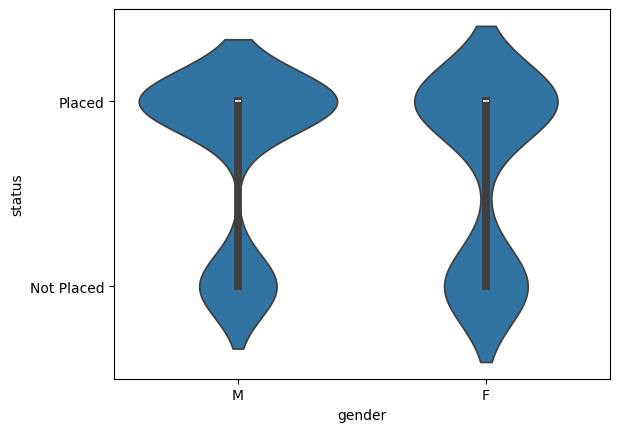

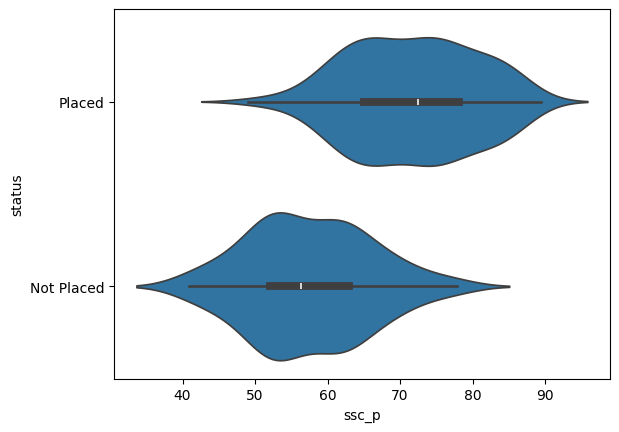

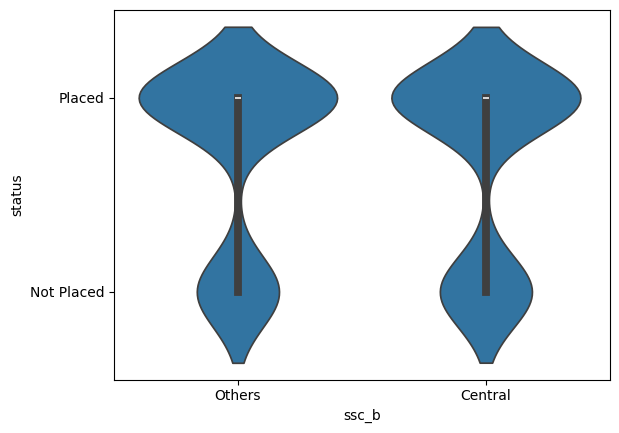

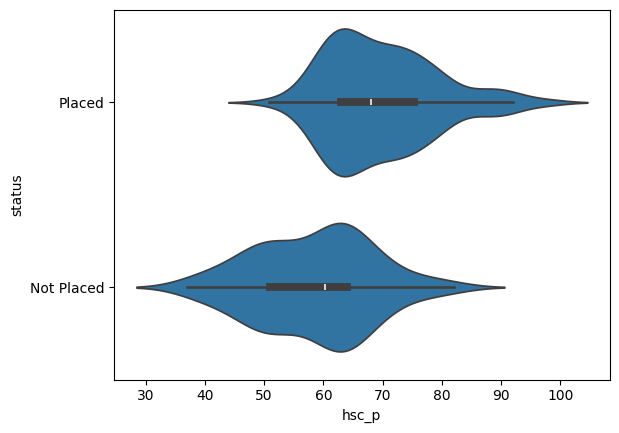

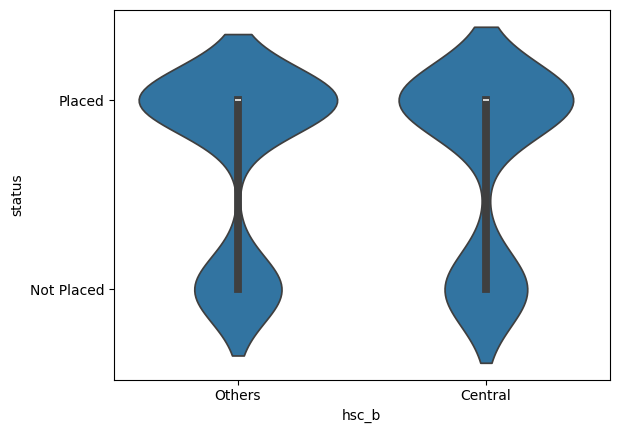

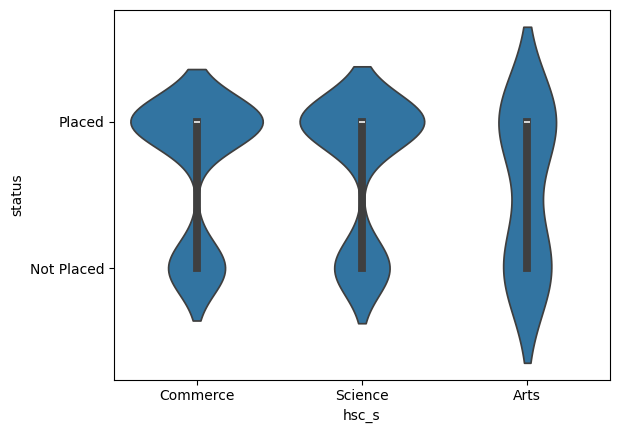

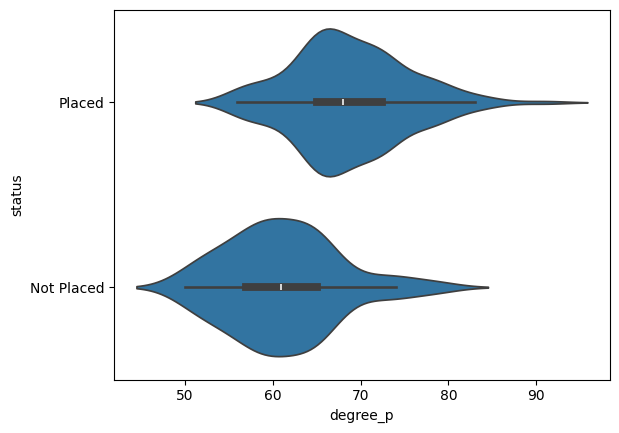

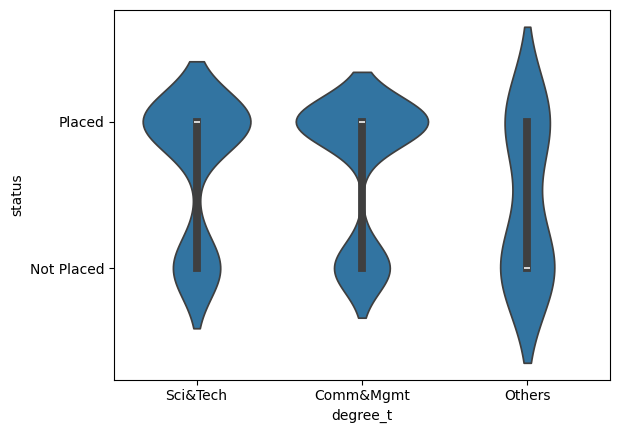

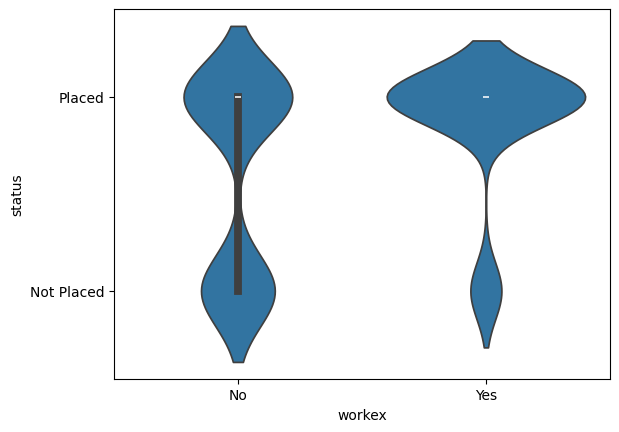

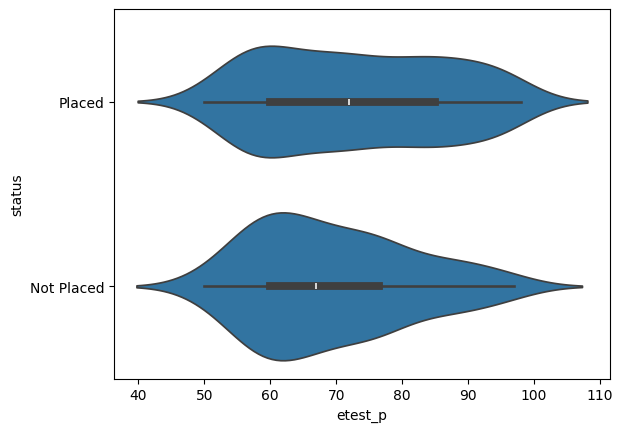

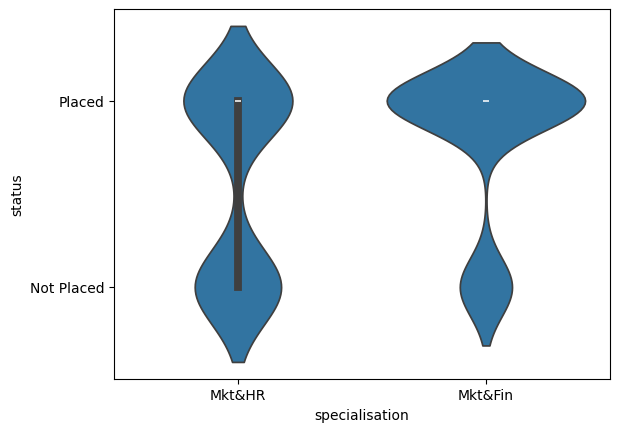

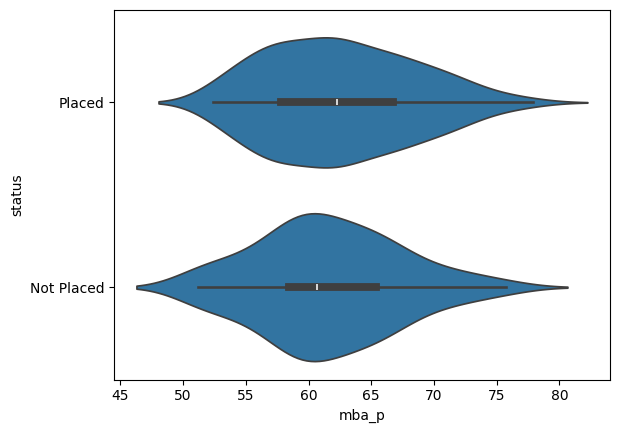

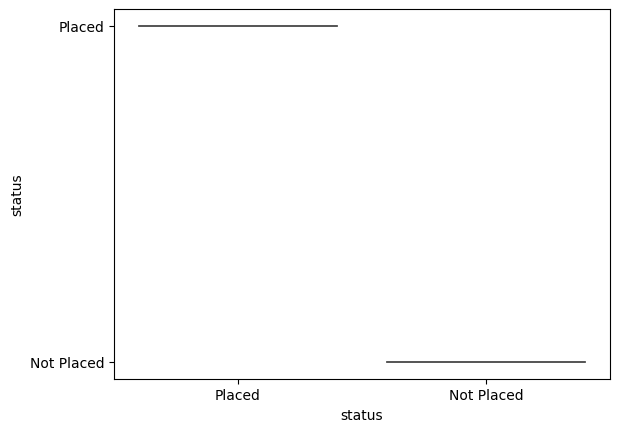

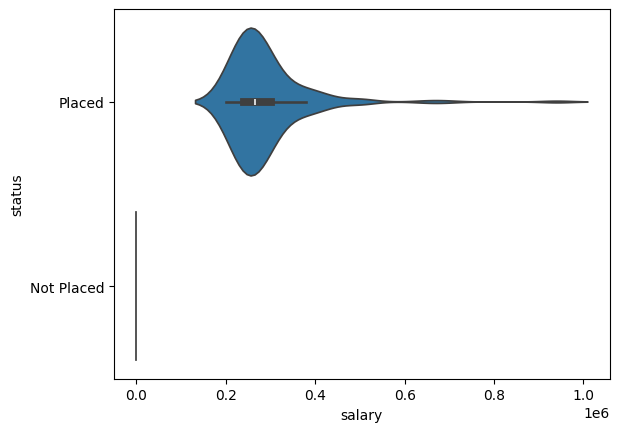

In [62]:
#  3)Find the reason for non placement from the dataset?

for feature in df.columns:
    sns.violinplot(data = df, x = feature, y = df['status'])
    plt.show()

In [7]:
from sklearn.ensemble import RandomForestClassifier

target = df['status']
features = df.drop(['status', 'salary'], axis = 1)

features = pd.get_dummies(features, drop_first = True)

model = RandomForestClassifier()
model.fit(features, target)

print(pd.Series(data=  model.feature_importances_, index = model.feature_names_in_))

ssc_p                    0.277194
hsc_p                    0.180804
degree_p                 0.185754
etest_p                  0.077394
mba_p                    0.115747
gender_M                 0.020714
ssc_b_Others             0.017686
hsc_b_Others             0.017124
hsc_s_Commerce           0.009567
hsc_s_Science            0.013174
degree_t_Others          0.006013
degree_t_Sci&Tech        0.012726
workex_Yes               0.039457
specialisation_Mkt&HR    0.026645
dtype: float64


correlation:  0.13982273892615565


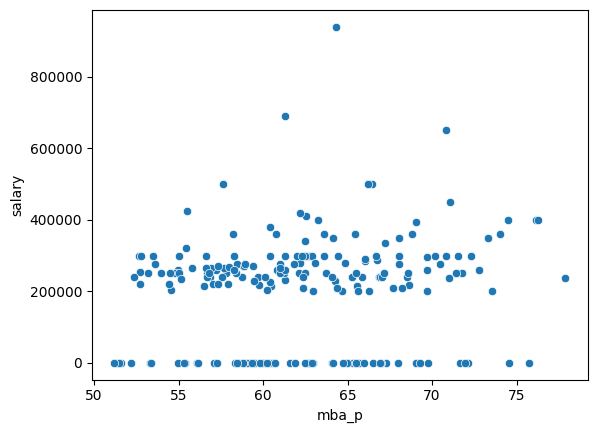

In [8]:
# 4)What kind of relation between salary and mba_p

sns.scatterplot(data = df, y = df['salary'], x=df['mba_p'])
print("correlation: ", df['mba_p'].corr(df['salary']))

In [72]:
# 5)Which specialization is getting minimum salary?

df[df['salary'] > 0].sort_values(by = 'salary', ascending = True)

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.50,Mkt&Fin,66.28,Placed,200000.0
15,F,65.00,Central,75.00,Central,Commerce,69.00,Comm&Mgmt,Yes,72.00,Mkt&Fin,64.66,Placed,200000.0
44,F,77.00,Others,73.00,Others,Commerce,81.00,Comm&Mgmt,Yes,89.00,Mkt&Fin,69.70,Placed,200000.0
50,F,75.20,Central,73.20,Central,Science,68.40,Comm&Mgmt,No,65.00,Mkt&HR,62.98,Placed,200000.0
135,F,72.00,Central,56.00,Others,Science,69.00,Comm&Mgmt,No,55.60,Mkt&HR,65.63,Placed,200000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,M,64.00,Others,80.00,Others,Science,65.00,Sci&Tech,Yes,69.00,Mkt&Fin,57.65,Placed,500000.0
163,M,63.00,Others,67.00,Others,Science,64.00,Sci&Tech,No,75.00,Mkt&Fin,66.46,Placed,500000.0
177,F,73.00,Central,97.00,Others,Commerce,79.00,Comm&Mgmt,Yes,89.00,Mkt&Fin,70.81,Placed,650000.0
150,M,71.00,Central,58.66,Central,Science,58.00,Sci&Tech,Yes,56.00,Mkt&Fin,61.30,Placed,690000.0


In [9]:
# 6)How many of them getting above 500000 salary?

df[df['salary'] > 500000]

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
119,M,60.8,Central,68.40,Central,Commerce,64.6,Comm&Mgmt,Yes,82.66,Mkt&Fin,64.34,Placed,940000.0
150,M,71.0,Central,58.66,Central,Science,58.0,Sci&Tech,Yes,56.00,Mkt&Fin,61.30,Placed,690000.0
177,F,73.0,Central,97.00,Others,Commerce,79.0,Comm&Mgmt,Yes,89.00,Mkt&Fin,70.81,Placed,650000.0


In [10]:
# 7)Test the Analysis of Variance between mba_p and specialisation at
# signifance level 5%.(Make decision using Hypothesis Testing)

# H0 -> There is no difference 
# Alternative hypo -> rejection of H0.

from scipy.stats import f_oneway

grp1 = df[df['specialisation'] == 'Mkt&HR']['mba_p']
grp2 = df[df['specialisation'] == 'Mkt&Fin']['mba_p']

f_stat, p_value = f_oneway(grp1, grp2)
print(f"statistical: {f_stat} & p_value : {p_value}")

if p_value < 0.05:
    print("Fail to reject null hypothesis")
else:
    print("Null hypothesis is rejected")

statistical: 2.407910035610579 & p_value : 0.12220798673485479
Null hypothesis is rejected


In [11]:
# 8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR)
# with respect to salary at significance level of 5%.(Make decision using Hypothesis Testing)

from scipy.stats import ttest_ind

grp1 = df[df['degree_t'] == 'Sci&Tech']['salary']
grp2 = df[df['specialisation'] == 'Mkt&HR']['salary']

t_stat, p_value = ttest_ind(grp1, grp2)
print(f"statistical: {t_stat} & p_value : {p_value}")

if p_value < 0.05:
    print("Fail to reject null hypothesis")
else:
    print("Null hypothesis is rejected")

statistical: 2.692041243555374 & p_value : 0.007897969943471179
Fail to reject null hypothesis


<Axes: ylabel='Count'>

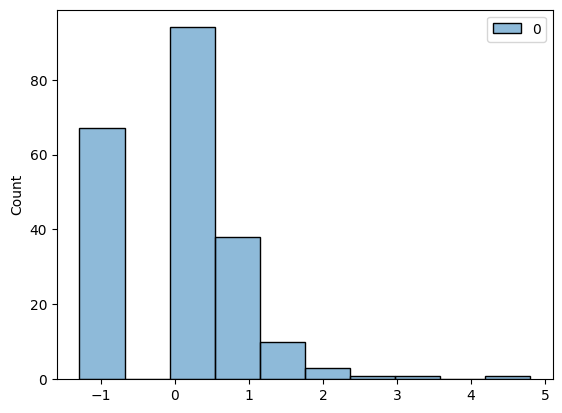

In [14]:
# 9)Convert the normal distribution to standard normal distribution for salary column

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
salary_scaled = sc.fit_transform(df[['salary']])
sns.histplot(salary_scaled)

In [ ]:
# 11)Test the similarity between the degree_t(Sci&Tech)with respect to 
# etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

from scipy.stats import ttest_rel

grp1 = df[df['degree_t'] == 'Sci&Tech']['etest_p']
grp2 = df[df['degree_t'] == 'Sci&Tech']['mba_p']

t_stat, p_value = ttest_rel(grp1, grp2)
print(f"statistical: {t_stat} & p_value : {p_value}")

if p_value < 0.05:
    print("Fail to reject null hypothesis")
else:
    print("Null hypothesis is rejected")

# 0.00000051

statistical: 5.0049844583693615 & p_value : 5.517920600505392e-06
Fail to reject null hypothesis


<Axes: >

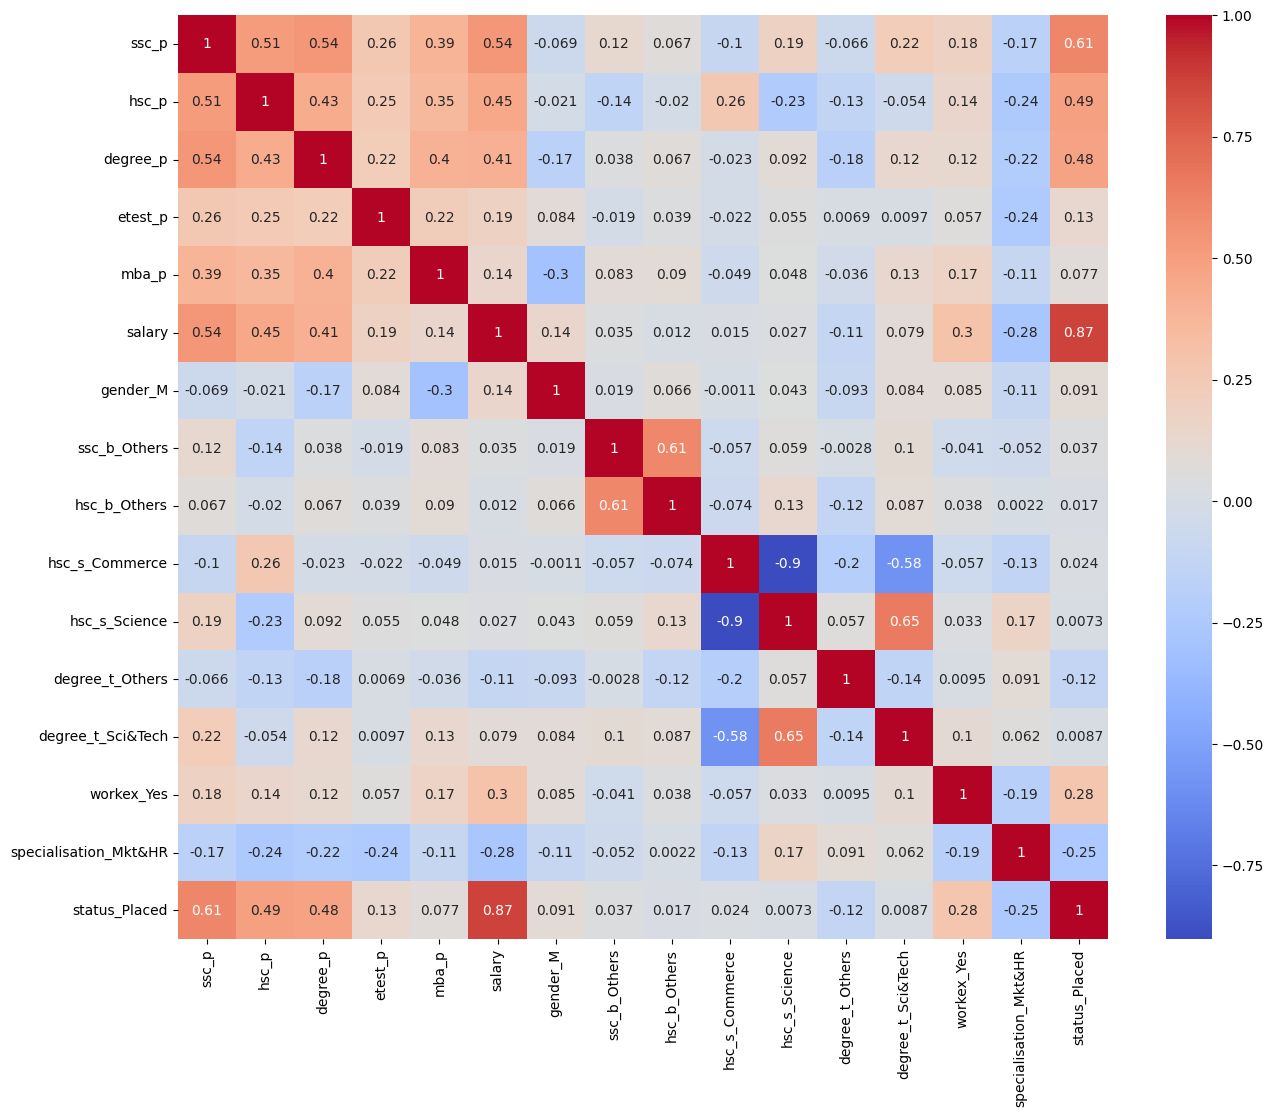

In [101]:
# 12)Which parameter is highly correlated with salary?

encoded_data  = pd.get_dummies(df, drop_first =True)

plt.figure(figsize=(15,12))
sns.heatmap(data = encoded_data.corr(), annot = True, cmap = 'coolwarm')